In [ ]:
# ========================================
# JUPYTER NOTEBOOK - WASTE DETECTION SYSTEM
# Complete working code for Jupyter
# ========================================

# ============ CELL 1: Setup & Imports ============
import sys
import os
from pathlib import Path
import cv2
import numpy as np
from datetime import datetime
import time
from collections import deque, Counter

# Set working directory to your project folder
PROJECT_DIR = r'C:\Users\WIN10\Desktop\Projects\waste-detection-production'
os.chdir(PROJECT_DIR)

print("="*70)
print("WASTE DETECTION SYSTEM - JUPYTER NOTEBOOK")
print("="*70)
print(f"Working Directory: {os.getcwd()}")
print(f"Model exists: {Path('models/best.pt').exists()}")

# Verify model file
model_path = Path('models/best.pt')
if model_path.exists():
    size_mb = model_path.stat().st_size / (1024 * 1024)
    print(f"✓ Model found: {size_mb:.2f} MB")
else:
    print(f"❌ Model not found at: {model_path.absolute()}")
    print("\nSearching for best.pt...")
    for p in Path('.').rglob('best.pt'):
        print(f"  Found at: {p}")

# ============ CELL 2: Import YOLO ============
from ultralytics import YOLO

print("\n✓ Ultralytics imported")

# ============ CELL 3: Configuration ============
# Camera settings
PHONE_IP = "192.168.0.105"  # Update this!
CAMERA_NAME = "Main River Camera"
CAMERA_LOCATION = "River Section A"

# Detection settings
CONFIDENCE_THRESHOLD = 0.65
IOU_THRESHOLD = 0.4
MIN_BOX_AREA = 2000
SMOOTHING_WINDOW = 25
STABILITY_FRAMES = 18
ALERT_THRESHOLD = 5

# Paths
MODEL_PATH = 'models/best.pt'
SAVE_DETECTIONS = True
DETECTION_FOLDER = 'detections'

# Create detection folder
os.makedirs(DETECTION_FOLDER, exist_ok=True)

print("\n✓ Configuration loaded")
print(f"  Phone IP: {PHONE_IP}")
print(f"  Model: {MODEL_PATH}")
print(f"  Alert Threshold: {ALERT_THRESHOLD} items")

# ============ CELL 4: Load Model ============
print("\nLoading YOLOv11 model...")

# Convert to absolute path to avoid issues
model_path_abs = Path(MODEL_PATH).absolute()
print(f"Absolute path: {model_path_abs}")

if not model_path_abs.exists():
    raise FileNotFoundError(f"Model not found: {model_path_abs}")

model = YOLO(str(model_path_abs))
print("✓ Model loaded successfully!")

# Warm up model
dummy_img = np.zeros((640, 640, 3), dtype=np.uint8)
_ = model.predict(dummy_img, verbose=False)
print("✓ Model warmed up")

# ============ CELL 5: Helper Functions ============
def calculate_box_area(box):
    """Calculate bounding box area"""
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    return (x2 - x1) * (y2 - y1)

def filter_detections(boxes):
    """Filter detections by confidence and size"""
    if boxes is None or len(boxes) == 0:
        return [], []
    
    valid_boxes = []
    valid_confidences = []
    
    for box in boxes:
        conf = box.conf[0].item()
        area = calculate_box_area(box)
        
        if conf >= CONFIDENCE_THRESHOLD and area >= MIN_BOX_AREA:
            valid_boxes.append(box)
            valid_confidences.append(conf)
    
    return valid_boxes, valid_confidences

def get_stable_count(history, min_frames):
    """Get most stable count from history"""
    if len(history) < min_frames:
        return None
    
    recent = list(history)[-min_frames:]
    count_freq = Counter(recent)
    
    if not count_freq:
        return 0
    
    most_common_count, frequency = count_freq.most_common(1)[0]
    
    if frequency >= min_frames * 0.85:
        return most_common_count
    
    return None

def save_detection_image(frame, count, confidence):
    """Save annotated detection image"""
    if not SAVE_DETECTIONS:
        return None
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"{DETECTION_FOLDER}/det_{count}items_conf{confidence:.0%}_{timestamp}.jpg"
    cv2.imwrite(filename, frame)
    return filename

print("✓ Helper functions loaded")

# ============ CELL 6: Connect to Camera ============
camera_url = f"http://{PHONE_IP}:8080/video"
print(f"\nConnecting to camera: {camera_url}")

cap = cv2.VideoCapture(camera_url)
cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)

if not cap.isOpened():
    print("❌ Camera connection failed!")
    print("\nTroubleshooting:")
    print("1. Make sure IP Webcam app is running")
    print("2. Check phone and PC are on same WiFi")
    print("3. Verify IP address is correct")
else:
    print("✓ Camera connected!")

# ============ CELL 7: MAIN DETECTION LOOP ============
# Tracking variables
detection_history = deque(maxlen=SMOOTHING_WINDOW)
confidence_history = deque(maxlen=SMOOTHING_WINDOW)
current_stable_count = 0
last_report_time = 0
frame_count = 0
skip_frames = 0

# Metrics
total_detections = 0
high_conf_detections = 0

# FPS
fps_start = time.time()
fps_count = 0
current_fps = 0

print("\n" + "="*70)
print("🎥 DETECTION STARTED")
print("="*70)
print("Controls:")
print("  'q' = Quit")
print("  's' = Save screenshot")
print("  'r' = Reset")
print("="*70 + "\n")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("⚠️ Connection lost")
            break
        
        frame_count += 1
        fps_count += 1
        
        # Skip frames for performance
        skip_frames += 1
        if skip_frames < 2:
            continue
        skip_frames = 0
        
        # Calculate FPS
        if time.time() - fps_start >= 1.0:
            current_fps = fps_count / (time.time() - fps_start)
            fps_start = time.time()
            fps_count = 0
        
        # Run detection with tracking
        try:
            results = model.track(
                frame,
                conf=CONFIDENCE_THRESHOLD,
                iou=IOU_THRESHOLD,
                imgsz=640,
                verbose=False,
                persist=True,
                tracker="bytetrack.yaml",
                max_det=15
            )
        except Exception as e:
            print(f"⚠️ Detection error: {e}")
            continue
        
        # Filter detections
        raw_boxes = results[0].boxes
        filtered_boxes, confidences = filter_detections(raw_boxes)
        current_count = len(filtered_boxes)
        
        # Update metrics
        if current_count > 0:
            avg_conf = np.mean(confidences)
            max_conf = np.max(confidences)
            confidence_history.append(avg_conf)
            
            for c in confidences:
                total_detections += 1
                if c > 0.7:
                    high_conf_detections += 1
        else:
            avg_conf = max_conf = 0
            confidence_history.append(0)
        
        detection_history.append(current_count)
        
        # Calculate overall confidence
        avg_confidence = np.mean([c for c in confidence_history if c > 0]) if any(confidence_history) else 0
        
        # Get stable count
        stable_count = get_stable_count(detection_history, STABILITY_FRAMES)
        
        # Process stable detections
        current_time = time.time()
        if stable_count is not None and stable_count != current_stable_count:
            if current_time - last_report_time >= 2.5:
                current_stable_count = stable_count
                last_report_time = current_time
                
                if stable_count > 0:
                    print(f"🚨 DETECTED: {stable_count} items | Confidence: {avg_confidence:.1%}")
                    
                    # Check for alerts
                    if stable_count >= ALERT_THRESHOLD:
                        print(f"⚠️  ALERT THRESHOLD EXCEEDED! ({stable_count} >= {ALERT_THRESHOLD})")
                else:
                    print("✓ Clear - No plastic detected")
        
        # Annotate frame
        annotated = frame.copy()
        
        # Draw detection boxes
        for i, box in enumerate(filtered_boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            conf = confidences[i]
            
            color = (0, 255, 0) if conf > 0.8 else (0, 255, 255) if conf > 0.7 else (0, 165, 255)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            
            label = f"Plastic {conf:.2%}"
            if raw_boxes.id is not None and i < len(raw_boxes.id):
                label = f"ID{int(raw_boxes.id[i])} {conf:.2%}"
            
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(annotated, (x1, y1-th-10), (x1+tw, y1), color, -1)
            cv2.putText(annotated, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
        
        # Draw info panel
        overlay = annotated.copy()
        cv2.rectangle(overlay, (5, 5), (380, 220), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.7, annotated, 0.3, 0, annotated)
        
        y = 40
        cv2.putText(annotated, f"COUNT: {current_stable_count}", (15, y), cv2.FONT_HERSHEY_DUPLEX, 1.3, (0,255,0), 3)
        y += 45
        
        cv2.putText(annotated, f"Raw: {len(raw_boxes)} | Filtered: {current_count}", (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 2)
        y += 28
        
        if avg_confidence > 0:
            acc_color = (0,255,0) if avg_confidence > 0.75 else (0,165,255)
            cv2.putText(annotated, f"Accuracy: {avg_confidence:.1%}", (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, acc_color, 2)
        y += 30
        
        if len(detection_history) >= STABILITY_FRAMES:
            recent = list(detection_history)[-STABILITY_FRAMES:]
            stability = (recent.count(current_stable_count) / STABILITY_FRAMES) * 100
            status = "LOCKED" if stability >= 85 else "STABLE" if stability >= 70 else "TRACKING"
            color_map = {"LOCKED": (0,255,0), "STABLE": (0,200,255), "TRACKING": (0,100,255)}
            cv2.putText(annotated, f"Status: {status} ({stability:.0f}%)", (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color_map[status], 2)
        else:
            remaining = STABILITY_FRAMES - len(detection_history)
            cv2.putText(annotated, f"Calibrating: {remaining} frames", (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,200,0), 2)
        y += 28
        
        cv2.putText(annotated, f"FPS: {current_fps:.1f}", (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        
        # Display
        cv2.imshow('Plastic Detection - Press Q to Quit', annotated)
        
        # Key controls
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('s'):
            filename = save_detection_image(annotated, current_stable_count, avg_confidence)
            print(f"📸 Screenshot saved: {filename}")
        elif key == ord('r'):
            detection_history.clear()
            confidence_history.clear()
            current_stable_count = 0
            print("🔄 System reset")

except KeyboardInterrupt:
    print("\n⚠️ Stopped by user")
finally:
    cap.release()
    cv2.destroyAllWindows()
    
    print("\n" + "="*70)
    print("DETECTION SESSION SUMMARY")
    print("="*70)
    print(f"Total frames: {frame_count}")
    print(f"Final count: {current_stable_count}")
    if avg_confidence > 0:
        print(f"Avg confidence: {avg_confidence:.1%}")
    if total_detections > 0:
        high_conf_ratio = (high_conf_detections / total_detections) * 100
        print(f"High confidence ratio: {high_conf_ratio:.1f}%")
    print("="*70)

# ============ CELL 8: View Saved Detections ============
# Run this cell to see saved detection images
from IPython.display import Image, display
import glob

saved_images = glob.glob(f"{DETECTION_FOLDER}/*.jpg")
print(f"Found {len(saved_images)} saved detections")

if saved_images:
    # Show latest 3
    for img_path in sorted(saved_images)[-3:]:
        print(f"\n{Path(img_path).name}")
        display(Image(filename=img_path, width=800))
else:
    print("No saved detections yet")

PRODUCTION WASTE DETECTION SYSTEM v2.0
Directory: C:\Users\WIN10\Desktop\Projects\waste-detection-production
Model: True

Loading model: best.pt
✓ Model loaded and ready

✓ Optimized configuration loaded
  Confidence: 0.7
  Stability: 90.0%
  Alert Threshold: 5 items
✓ Advanced helper functions loaded

Connecting to: http://192.168.0.103:8080/video
✓ Camera connected

🎥 DETECTION STARTED - OPTIMIZED MODE
Controls: 'q'=quit | 's'=save | 'r'=reset | 'p'=pause

🗑️ DETECTED: 1 plastic item(s) | Confidence: 84.2% | Quality: 81.9%
   📸 Saved: detections/plastic_1items_84%_20251111_151919.jpg
✓ Clear - No plastic detected
🗑️ DETECTED: 1 plastic item(s) | Confidence: 87.3% | Quality: 87.5%
   📸 Saved: detections/plastic_1items_87%_20251111_151959.jpg
📸 Screenshot saved: detections/plastic_1items_90%_20251111_152007.jpg

🛑 Stopping detection...

DETECTION SESSION SUMMARY
Total Frames Processed: 658
Final Stable Count: 1 items
Average Confidence: 89.1%
Average Quality Score: 92.1%
High Confidenc

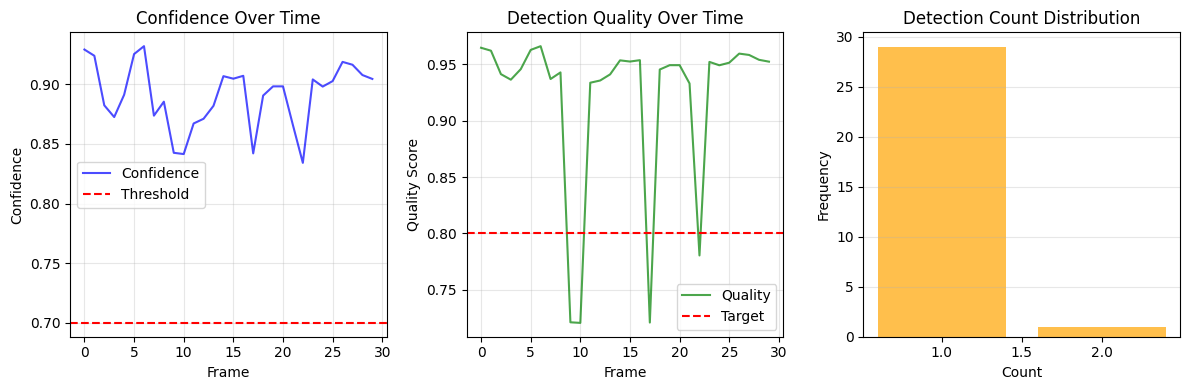

✓ Analysis charts saved as 'detection_analysis.png'


In [1]:
# ========================================
# PRODUCTION-GRADE WASTE DETECTION SYSTEM
# Optimized for Maximum Accuracy & Stability
# ========================================

# ============ CELL 1: Setup ============
import sys
import os
from pathlib import Path
import cv2
import numpy as np
from datetime import datetime
import time
from collections import deque, Counter

# Set working directory
PROJECT_DIR = r'C:\Users\WIN10\Desktop\Projects\waste-detection-production'
os.chdir(PROJECT_DIR)

print("="*70)
print("PRODUCTION WASTE DETECTION SYSTEM v2.0")
print("="*70)
print(f"Directory: {os.getcwd()}")
print(f"Model: {Path('models/best.pt').exists()}")

# ============ CELL 2: Import & Load Model ============
from ultralytics import YOLO

MODEL_PATH = 'models/best.pt'
model_abs_path = Path(MODEL_PATH).absolute()

if not model_abs_path.exists():
    raise FileNotFoundError(f"Model not found: {model_abs_path}")

print(f"\nLoading model: {model_abs_path.name}")
model = YOLO(str(model_abs_path))

# Warm up
_ = model.predict(np.zeros((640, 640, 3), dtype=np.uint8), verbose=False)
print("✓ Model loaded and ready")

# ============ CELL 3: OPTIMIZED CONFIGURATION ============

# Camera
PHONE_IP = "192.168.0.103"  # UPDATE THIS
CAMERA_NAME = "Main River Camera"
CAMERA_LOCATION = "River Section A"

# Detection (OPTIMIZED)
CONFIDENCE_THRESHOLD = 0.70    # Higher = fewer false positives
IOU_THRESHOLD = 0.45           # Better overlap handling
MIN_BOX_AREA = 1500            # Smaller objects detected
IMAGE_SIZE = 640               # Try 1280 for better accuracy

# Tracking (OPTIMIZED FOR STABILITY)
SMOOTHING_WINDOW = 30
STABILITY_FRAMES = 20
STABILITY_THRESHOLD = 0.90     # 90% consistency required

# Alerts
ALERT_THRESHOLD = 5
REPORT_COOLDOWN = 3.0

# Visualization (BETTER COLORS)
COLORS = {
    'high': (0, 255, 0),       # Green >85%
    'medium': (0, 255, 255),   # Yellow 70-85%
    'low': (0, 165, 255)       # Orange <70%
}

# Paths
SAVE_DETECTIONS = True
DETECTION_FOLDER = 'detections'
os.makedirs(DETECTION_FOLDER, exist_ok=True)

print("\n✓ Optimized configuration loaded")
print(f"  Confidence: {CONFIDENCE_THRESHOLD}")
print(f"  Stability: {STABILITY_THRESHOLD*100}%")
print(f"  Alert Threshold: {ALERT_THRESHOLD} items")

# ============ CELL 4: ADVANCED HELPER FUNCTIONS ============

def calculate_box_area(box):
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    return (x2 - x1) * (y2 - y1)

def advanced_filter_detections(boxes, frame_shape):
    """Enhanced filtering with multiple criteria"""
    if boxes is None or len(boxes) == 0:
        return [], [], []
    
    h, w = frame_shape[:2]
    valid_boxes = []
    valid_confidences = []
    valid_ids = []
    
    for idx, box in enumerate(boxes):
        conf = box.conf[0].item()
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        
        box_w = x2 - x1
        box_h = y2 - y1
        area = box_w * box_h
        aspect_ratio = box_w / box_h if box_h > 0 else 0
        
        # Multi-criteria validation
        valid = True
        
        # Confidence
        if conf < CONFIDENCE_THRESHOLD:
            valid = False
        
        # Size
        if area < MIN_BOX_AREA:
            valid = False
        
        # Aspect ratio (avoid weird shapes)
        if aspect_ratio < 0.1 or aspect_ratio > 10:
            valid = False
        
        # Boundary check
        margin = 10
        if (x1 < margin or y1 < margin or 
            x2 > w-margin or y2 > h-margin):
            if area < MIN_BOX_AREA * 2:
                valid = False
        
        # Relative size
        image_area = w * h
        relative_size = area / image_area
        if relative_size < 0.001 or relative_size > 0.8:
            valid = False
        
        if valid:
            valid_boxes.append(box)
            valid_confidences.append(conf)
            # Get tracking ID if available
            if boxes.id is not None and idx < len(boxes.id):
                valid_ids.append(int(boxes.id[idx]))
            else:
                valid_ids.append(None)
    
    return valid_boxes, valid_confidences, valid_ids

def get_stable_count_advanced(history, min_frames, threshold=STABILITY_THRESHOLD):
    """Advanced stability calculation"""
    if len(history) < min_frames:
        return None
    
    recent = list(history)[-min_frames:]
    count_freq = Counter(recent)
    
    if not count_freq:
        return 0
    
    most_common_count, frequency = count_freq.most_common(1)[0]
    stability_ratio = frequency / min_frames
    
    if stability_ratio >= threshold:
        return most_common_count
    
    return None

def calculate_detection_quality(confidences):
    """Calculate overall detection quality score"""
    if not confidences:
        return 0.0
    
    avg_conf = np.mean(confidences)
    std_conf = np.std(confidences) if len(confidences) > 1 else 0
    consistency_score = 1 - min(std_conf, 0.3) / 0.3
    high_conf_ratio = sum(1 for c in confidences if c > 0.85) / len(confidences)
    
    quality_score = (
        avg_conf * 0.5 +
        consistency_score * 0.3 +
        high_conf_ratio * 0.2
    )
    
    return quality_score

def save_detection_image(frame, count, confidence):
    if not SAVE_DETECTIONS:
        return None
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"{DETECTION_FOLDER}/plastic_{count}items_{confidence:.0%}_{timestamp}.jpg"
    cv2.imwrite(filename, frame)
    return filename

print("✓ Advanced helper functions loaded")

# ============ CELL 5: Connect Camera ============
camera_url = f"http://{PHONE_IP}:8080/video"
print(f"\nConnecting to: {camera_url}")

cap = cv2.VideoCapture(camera_url)
cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)

if not cap.isOpened():
    print("❌ Camera connection failed!")
    raise ConnectionError("Cannot connect to camera")

print("✓ Camera connected")

# ============ CELL 6: MAIN DETECTION LOOP (OPTIMIZED) ============

# Tracking variables
detection_history = deque(maxlen=SMOOTHING_WINDOW)
confidence_history = deque(maxlen=SMOOTHING_WINDOW)
quality_history = deque(maxlen=SMOOTHING_WINDOW)
current_stable_count = 0
last_report_time = 0
frame_count = 0

# Metrics
total_detections = 0
high_conf_detections = 0
detection_sessions = []

# FPS
fps_start = time.time()
fps_count = 0
current_fps = 0

print("\n" + "="*70)
print("🎥 DETECTION STARTED - OPTIMIZED MODE")
print("="*70)
print("Controls: 'q'=quit | 's'=save | 'r'=reset | 'p'=pause")
print("="*70 + "\n")

paused = False

try:
    while True:
        if not paused:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ Connection lost")
                break
            
            frame_count += 1
            fps_count += 1
            
            # Calculate FPS
            if time.time() - fps_start >= 1.0:
                current_fps = fps_count / (time.time() - fps_start)
                fps_start = time.time()
                fps_count = 0
            
            # Run detection with tracking
            try:
                results = model.track(
                    frame,
                    conf=CONFIDENCE_THRESHOLD,
                    iou=IOU_THRESHOLD,
                    imgsz=IMAGE_SIZE,
                    verbose=False,
                    persist=True,
                    tracker="bytetrack.yaml",
                    max_det=20
                )
            except Exception as e:
                print(f"⚠️ Detection error: {e}")
                continue
            
            # Advanced filtering
            raw_boxes = results[0].boxes
            filtered_boxes, confidences, track_ids = advanced_filter_detections(
                raw_boxes, frame.shape
            )
            current_count = len(filtered_boxes)
            
            # Update metrics
            if current_count > 0:
                avg_conf = float(np.mean(confidences))
                max_conf = float(np.max(confidences))
                quality = calculate_detection_quality(confidences)
                confidence_history.append(avg_conf)
                quality_history.append(quality)
                
                for c in confidences:
                    total_detections += 1
                    if c > 0.85:
                        high_conf_detections += 1
            else:
                avg_conf = max_conf = quality = 0.0
                confidence_history.append(0)
                quality_history.append(0)
            
            detection_history.append(current_count)
            
            # Calculate overall statistics
            avg_confidence = float(np.mean([c for c in confidence_history if c > 0])) if any(confidence_history) else 0
            avg_quality = float(np.mean([q for q in quality_history if q > 0])) if any(quality_history) else 0
            
            # Get stable count with advanced algorithm
            stable_count = get_stable_count_advanced(detection_history, STABILITY_FRAMES, STABILITY_THRESHOLD)
            
            # Process stable detections
            current_time = time.time()
            if stable_count is not None and stable_count != current_stable_count:
                if current_time - last_report_time >= REPORT_COOLDOWN:
                    current_stable_count = stable_count
                    last_report_time = current_time
                    
                    if stable_count > 0:
                        quality_str = f"{avg_quality*100:.1f}%"
                        print(f"🗑️ DETECTED: {stable_count} plastic item(s) | Confidence: {avg_confidence:.1%} | Quality: {quality_str}")
                        
                        # Save high-quality detections
                        if avg_quality > 0.8:
                            img_path = save_detection_image(frame, stable_count, avg_confidence)
                            print(f"   📸 Saved: {img_path}")
                        
                        # Alert check
                        if stable_count >= ALERT_THRESHOLD:
                            print(f"   🚨 ALERT: Threshold exceeded ({stable_count} >= {ALERT_THRESHOLD})")
                    else:
                        print("✓ Clear - No plastic detected")
            
            # ============ ENHANCED VISUALIZATION ============
            annotated = frame.copy()
            
            # Draw detection boxes with improved labels
            for i, box in enumerate(filtered_boxes):
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = confidences[i]
                track_id = track_ids[i]
                
                # Color based on confidence
                if conf > 0.85:
                    color = COLORS['high']
                    conf_label = "HIGH"
                elif conf > 0.70:
                    color = COLORS['medium']
                    conf_label = "MED"
                else:
                    color = COLORS['low']
                    conf_label = "LOW"
                
                # Draw box with thicker lines
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 3)
                
                # Main label: "Plastic 87%"
                label = f"Plastic {conf:.0%}"
                
                # Draw label background
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                cv2.rectangle(annotated, (x1, y1 - th - 15), (x1 + tw + 10, y1), color, -1)
                
                # Draw main label
                cv2.putText(annotated, label, (x1 + 5, y1 - 8), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
                
                # Draw tracking ID as small subscript (if available)
                if track_id is not None:
                    id_label = f"#{track_id}"
                    cv2.putText(annotated, id_label, (x1 + 5, y1 + 20), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            # ============ ENHANCED INFO PANEL ============
            overlay = annotated.copy()
            cv2.rectangle(overlay, (5, 5), (420, 260), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.8, annotated, 0.2, 0, annotated)
            
            y = 40
            
            # Main count (large, bold)
            cv2.putText(annotated, f"COUNT: {current_stable_count}", 
                       (15, y), cv2.FONT_HERSHEY_DUPLEX, 1.4, (0, 255, 0), 3)
            y += 50
            
            # Detection counts
            cv2.putText(annotated, f"Raw: {len(raw_boxes)} | Filtered: {current_count}", 
                       (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)
            y += 30
            
            # Confidence (with quality indicator)
            if avg_confidence > 0:
                conf_color = (0, 255, 0) if avg_confidence > 0.80 else (0, 255, 255) if avg_confidence > 0.70 else (0, 165, 255)
                cv2.putText(annotated, f"Confidence: {avg_confidence:.1%}", 
                           (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, conf_color, 2)
            else:
                cv2.putText(annotated, "Confidence: N/A", 
                           (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (150, 150, 150), 2)
            y += 30
            
            # Quality score (NEW)
            if avg_quality > 0:
                quality_color = (0, 255, 0) if avg_quality > 0.85 else (0, 255, 255) if avg_quality > 0.70 else (0, 165, 255)
                cv2.putText(annotated, f"Quality: {avg_quality:.1%}", 
                           (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, quality_color, 2)
            y += 30
            
            # Stability status (enhanced)
            if len(detection_history) >= STABILITY_FRAMES:
                recent = list(detection_history)[-STABILITY_FRAMES:]
                stability = (recent.count(current_stable_count) / STABILITY_FRAMES) * 100
                
                if stability >= 90:
                    status, status_color = "LOCKED", (0, 255, 0)
                elif stability >= 75:
                    status, status_color = "STABLE", (0, 200, 255)
                elif stability >= 60:
                    status, status_color = "TRACKING", (0, 165, 255)
                else:
                    status, status_color = "UNSTABLE", (0, 100, 255)
                
                cv2.putText(annotated, f"Status: {status} ({stability:.0f}%)", 
                           (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)
            else:
                remaining = STABILITY_FRAMES - len(detection_history)
                cv2.putText(annotated, f"Calibrating: {remaining} frames", 
                           (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 200, 0), 2)
            y += 30
            
            # FPS
            cv2.putText(annotated, f"FPS: {current_fps:.1f}", 
                       (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
            y += 28
            
            # High confidence ratio
            if total_detections > 0:
                high_conf_ratio = (high_conf_detections / total_detections) * 100
                cv2.putText(annotated, f"High Conf: {high_conf_ratio:.0f}%", 
                           (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (100, 255, 100), 2)
            
            # Display
            cv2.imshow('Plastic Detection - Optimized | Press Q to Quit', annotated)
        
        else:
            # Show paused message
            paused_frame = frame.copy()
            cv2.putText(paused_frame, "PAUSED - Press 'p' to resume", 
                       (50, 50), cv2.FONT_HERSHEY_DUPLEX, 1, (0, 255, 255), 2)
            cv2.imshow('Plastic Detection - Optimized | Press Q to Quit', paused_frame)
        
        # Key controls
        key = cv2.waitKey(1) & 0xFF
        
        if key == ord('q'):
            print("\n🛑 Stopping detection...")
            break
        elif key == ord('s'):
            filename = save_detection_image(annotated, current_stable_count, avg_confidence)
            print(f"📸 Screenshot saved: {filename}")
        elif key == ord('r'):
            detection_history.clear()
            confidence_history.clear()
            quality_history.clear()
            current_stable_count = 0
            total_detections = 0
            high_conf_detections = 0
            print("🔄 System reset - recalibrating...")
        elif key == ord('p'):
            paused = not paused
            print(f"{'⏸️ PAUSED' if paused else '▶️ RESUMED'}")

except KeyboardInterrupt:
    print("\n⚠️ Stopped by user")

finally:
    cap.release()
    cv2.destroyAllWindows()
    
    # ============ FINAL STATISTICS ============
    print("\n" + "="*70)
    print("DETECTION SESSION SUMMARY")
    print("="*70)
    print(f"Total Frames Processed: {frame_count}")
    print(f"Final Stable Count: {current_stable_count} items")
    
    if avg_confidence > 0:
        print(f"Average Confidence: {avg_confidence:.1%}")
    
    if avg_quality > 0:
        print(f"Average Quality Score: {avg_quality:.1%}")
    
    if total_detections > 0:
        high_conf_ratio = (high_conf_detections / total_detections) * 100
        print(f"High Confidence Ratio: {high_conf_ratio:.1f}%")
        print(f"Total Detections Made: {total_detections}")
    
    # Calculate session stats
    if len(detection_history) > 0:
        non_zero = [d for d in detection_history if d > 0]
        if non_zero:
            print(f"Peak Count: {max(non_zero)} items")
            print(f"Average Count (when detected): {np.mean(non_zero):.1f} items")
    
    print(f"Session Duration: {frame_count / current_fps / 60:.1f} minutes" if current_fps > 0 else "")
    print("="*70)
    
    # Quality assessment
    print("\n📊 SYSTEM PERFORMANCE:")
    if avg_confidence > 0.85:
        print("✓ Excellent confidence levels")
    elif avg_confidence > 0.75:
        print("✓ Good confidence levels")
    else:
        print("⚠️ Consider retraining model for better accuracy")
    
    if avg_quality > 0.85:
        print("✓ Excellent detection quality")
    elif avg_quality > 0.70:
        print("✓ Good detection quality")
    else:
        print("⚠️ Detection quality could be improved")
    
    print("\n🎯 RECOMMENDATIONS:")
    if avg_confidence < 0.80:
        print("  - Retrain with YOLOv11 Large model")
        print("  - Increase training epochs to 150+")
        print("  - Add more training data")
    
    if current_fps < 10:
        print("  - Consider using smaller model (YOLOv11n)")
        print("  - Reduce image size to 416")
    
    if high_conf_detections < total_detections * 0.7:
        print("  - Increase confidence threshold to 0.75")
        print("  - Review and clean training data")
    
    print("\n✓ Detection session ended")
    print("="*70)

# ============ CELL 7: ANALYSIS & VISUALIZATION ============
# Run this after stopping detection

import matplotlib.pyplot as plt

print("\n" + "="*70)
print("DETECTION ANALYSIS")
print("="*70)

# Convert deques to lists for analysis
conf_data = [c for c in confidence_history if c > 0]
qual_data = [q for q in quality_history if q > 0]
det_data = list(detection_history)

if len(conf_data) > 10:
    # Plot confidence over time
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(conf_data, label='Confidence', color='blue', alpha=0.7)
    plt.axhline(y=0.7, color='r', linestyle='--', label='Threshold')
    plt.title('Confidence Over Time')
    plt.xlabel('Frame')
    plt.ylabel('Confidence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot quality over time
    plt.subplot(1, 3, 2)
    plt.plot(qual_data, label='Quality', color='green', alpha=0.7)
    plt.axhline(y=0.8, color='r', linestyle='--', label='Target')
    plt.title('Detection Quality Over Time')
    plt.xlabel('Frame')
    plt.ylabel('Quality Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot detection count distribution
    plt.subplot(1, 3, 3)
    count_freq = Counter(det_data)
    counts = sorted(count_freq.keys())
    freqs = [count_freq[c] for c in counts]
    plt.bar(counts, freqs, color='orange', alpha=0.7)
    plt.title('Detection Count Distribution')
    plt.xlabel('Count')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('detection_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Analysis charts saved as 'detection_analysis.png'")
else:
    print("⚠️ Not enough data for analysis")

print("="*70)